# Habit Formation

The standard assumption in consumption-saving models is that agents derive flow utility from current consumption $c_t$, and want to maximize the expected present discounted sum of current and future utility flows. An alternative assumption is that agents have *consumption habits* and get utility from both current consumption and from the *ratio* of their consumption relative to some habit stock $h_t$.

When making their consumption-saving decision, these consumers don't just need to account for how their current habit stock affects their (marginal) utility of consumption today, but also how their chosen consumption will affect their habit stock in the future, and hence their *future* utility flows.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from HARK.models import HabitConsumerType, IndShockConsumerType
from HARK.ConsumptionSaving.ConsIndShockModel import init_lifecycle
from HARK.utilities import plot_funcs, plot_func_slices
from time import time
from HARK.Calibration.Income.IncomeTools import (
    Cagetti_income,
    parse_income_spec,
    parse_time_params,
)
from HARK.Calibration.life_tables.us_ssa.SSATools import parse_ssa_life_table

mystr = lambda x: "{:.4f}".format(x)

## Statement of Habit-Formation Model

HARK's `HabitConsumerType` extends our workhorse `IndShockConsumerType` to include consumption habits that are updated as a linear combination of current consumption and the prior habit stock. The model is otherwise identical to `IndShockConsumerType`: agents can save in a single risk-free asset, they face permanent and transitory shocks to income, and have CRRA preferences over current utility flows and discount future utility flows geometrically. The agent's problem can be expressed in Bellman form as:

$$
\newcommand{\CRRA}{\rho}
\newcommand{\LivPrb}{\mathsf{S}}
\newcommand{\PermGroFac}{\Gamma}
\newcommand{\Rfree}{\mathsf{R}}
\newcommand{\DiscFac}{\beta}
\newcommand{\HabitWgt}{\alpha}
\newcommand{\HabitRte}{\lambda}
$$

\begin{align*}
        \text{v}_t(m_t,h_t) &= \max_{c_t}u(c_t,h_t) + \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{(1-\HabitWgt)(1-\CRRA)} \text{v}_{t+1}(m_{t+1}, h_{t+1}) \right] \\
        & \text{s.t.}  \\
        a_t &= m_t - c_t, \\
        H_t &= \HabitRte c_t + (1-\HabitRte) h_t, \\
        a_t &\geq \underline{a}, \\
        m_{t+1} &= a_t \Rfree_{t+1}/(\PermGroFac_{t+1} \psi_{t+1}) + \theta_{t+1}, \\
        h_{t+1} &= H_t / (\PermGroFac_{t+1} \psi_{t+1}), \\
        (\psi_{t+1},\theta_{t+1}) &\sim F_{t+1}, \\
        \mathbb{E}[\psi] &= 1, \\
        u(c,h) &= \frac{(c/h^\HabitWgt)^{1-\CRRA}}{1-\CRRA}.
\end{align*}

Compared to `IndShockConsumerType`, there are two new parameters for a `HabitConsumerType`: the "habit weight" $\HabitWgt$ and the "habit rate" $\HabitRte$. No, this is not confusing at all.

Habit weight $\HabitWgt$ is a preference parameter that represents how much weight the agent puts on the *ratio* of current consumption to prior habit stock; this parameter should always be on the unit interval. Note that the utility function can be rearranged to be a Cobb-Douglas combination of consumption $c_t$ and the consumption-to-habit ratio $c_t / h_t$:

\begin{equation*}
u(c,h) = \frac{(c/h^\HabitWgt)^{1-\CRRA}}{1-\CRRA} = \frac{\left( c^{1-\HabitWgt} \cdot (c/h)^\HabitWgt \right)^{1-\CRRA}}{1-\CRRA}.
\end{equation*}

As $\HabitWgt \rightarrow 0$, the model approaches the standard consumption-saving problem with no habits, as the agents put 100\% weight on current consumption. As $\HabitWgt \rightarrow 1$, agents care *only* about the rate of change of their consumption.

The habit rate parameter $\HabitRte$ governs how fast the habit stock is updated each period. If $\HabitRte$ is close to 1, end-of-period habit stock is updated (almost) completely with the newly chosen consumption, with little weight on consumption further in the past. When $\HabitRte$ is close to 0, then the habit stock evolves slowly, and past consumption choices will continue to affect utility far into the future.

As a special case, when $\HabitRte$ is exactly zero, *habits don't matter*. The level of the habit stock is permanently "stuck" and can never move, so the agents don't need to take account of how current consumption affects their future habit stock-- it won't. Their optimal consumption will be different from the baseline `IndShockConsumerType` when $\HabitWgt > 0$ because their "effective risk aversion" is lower, but there are no *dynamic* effects on consumption through habits.

## Solving the Habit-Formation Model

Like essentially all other HARK models, we solve the habit-formation model using (an extension of) the endogenous grid method (EGM). Unlike most models in HARK, there are two endogenous state dimensions, $m_t$ and $h_t$, but only one control variable, $c_t$. The first order condition for optimality is thus somewhat different than usual, and solving the first order condition to recover the optimal control is less straightforward.

### End-of-period (marginal) value

As usual, we begin by defining the end-of-period value function. For this model, there are two end-of-period states: retained assets $a_t$ and post-consumption habit stock $H_t$.

\begin{align*}
\mathfrak{v}_t(a_t,H_t) &= \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{(1-\HabitWgt)(1-\CRRA)} \text{v}_{t+1}(m_{t+1}, h_{t+1}) \right] \\
&\text{s.t.} \\
m_{t+1} &= a_t \Rfree_{t+1}/(\PermGroFac_{t+1} \psi_{t+1}) + \theta_{t+1}, \\
h_{t+1} &= H_t / (\PermGroFac_{t+1} \psi_{t+1}), \\
(\psi_{t+1},\theta_{t+1}) &\sim F_{t+1}.
\end{align*}

Marginal value with respect to each end-of-period state can be found as:
\begin{align*}
\mathfrak{v}_t^a(a_t,H_t) &= \Rfree_{t+1} \DiscFac \LivPrb_t \mathbb{E}_{t} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^m(m_{t+1}, h_{t+1}) \right], \\
\mathfrak{v}_t^H(a_t,H_t) &= \DiscFac \LivPrb_t  \mathbb{E}_{t} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{\HabitWgt\CRRA-\HabitWgt-\CRRA} \text{v}_{t+1}^h(m_{t+1}, h_{t+1}) \right].
\end{align*}

The Bellman form of the problem is then reduced to simply:

\begin{align*}
\text{v}_t(m_t,h_t) &= \max_{c_t} u(c_t,h_t) + \mathfrak{v}_t(a_t,H_t) \\
& \text{s.t.}  \\
a_t &= m_t - c_t, \\
H_t &= \HabitRte c_t + (1-\HabitRte) h_t, \\
a_t &\geq \underline{a}.
\end{align*}

### First order condition for optimal consumption

This problem has one first order condition for optimality (of an interior solution):

\begin{align*}
u^c(c_t,h_t) - \mathfrak{v}_t^a(a_t,H_t) + \HabitRte \mathfrak{v}_t^H(a_t,H_t) = 0 \\
\Longrightarrow h_t^{-\HabitRte(1-\CRRA)} c_t^{-\CRRA} = \mathfrak{v}_t^a(a_t,H_t) - \HabitRte \mathfrak{v}_t^H(a_t,H_t).
\end{align*}

Suppose we were at the end of the period, at some given $(a_t,H_t)$ and wanted to recover the control $c_t$ that must have *just been chosen* if ending the period in this way was optimal. The RHS of the FOC has only information that is available at the end of period $t$, and the LHS has our unknown variables... but there are two unknowns ($c_t$ and $h_t$) and only one equation!

To solve the first order condition, we need to bring in additional information about the relationship among $c_t$, $h_t$, and $H_t$: the law of motion that governs how the habit stock evolves. Then we will have two equations with two unknowns and can make more progress.

\begin{align*}
H_t &= \HabitRte c_t + (1-\HabitRte) h_t, \\
h_t^{-\HabitRte(1-\CRRA)} c_t^{-\CRRA} &= \mathfrak{v}_t^a(a_t,H_t) - \HabitRte \mathfrak{v}_t^H(a_t,H_t).
\end{align*}

We can rearrange the first order condition to isolate $c_t$ on the LHS, and then substitute that expression into the law of motion:
\begin{align*}
c_t^{-\CRRA} &= (\mathfrak{v}_t^a(a_t,H_t) - \HabitRte \mathfrak{v}_t^H(a_t,H_t)) h_t^{\HabitRte(1-\CRRA)} \\
\Longrightarrow c_t &= \underbrace{(\mathfrak{v}_t^a(a_t,H_t) - \HabitRte \mathfrak{v}_t^H(a_t,H_t))^{-1/\CRRA}}_{\equiv \chi} h_t^{\HabitRte(1-1/\CRRA)} \\
\Longrightarrow H_t &= \HabitRte \underbrace{\chi h_t^{\HabitRte(1-1/\CRRA)}}_{=c_t} + (1-\HabitRte) h_t.
\end{align*}

Note that the value $\chi$ depends only on the end of period state $(a_t, H_t)$. We now have one equation with one unknown variable. If we knew $\chi$ and $h_t$, then calculating $H_t$ would be easy... but when solving for optimal controls from the end of the period, we know $H_t$ and $\chi$ and want to recover $h_t$! Don't worry, we still have a way forward.

### Solving the FOC for optimal consumption and the endogenous gridpoints

Like in a couple other HARK models, we can *interpolate the inverse* of a function that's easy to construct, and then use that interpolant to solve the first order conditions. In a pre-solution step, HARK builds an interpolated function $Q(H, \chi)$ with the following procedure:

1. Choose exogenous grids of $h$ and $\chi$.
2. Evaluate the expression above to get $H$ from $h$ and $\chi$.
3. For each value of $\chi$, make a linear interpolation of $h$ over $H$.
4. Assemble a linear interpolant over $\chi$ for those linear interpolations; this is $Q(\cdot)$.

The $Q(\cdot)$ function yields the $h_t$ that the agent must have *begun* the period with if they are ending the period with $H_t$ in post-habit stock and have a "transformed end-of-period marginal value" of $\chi$. With both $h_t$ and $H_t$ known, their chosen consumption level can then be recovered by solving the law of motion for the habit stock:

\begin{align*}
H_t &= \HabitRte c_t + (1-\HabitRte) h_t \\
\Longrightarrow c_t &= (H_t - (1-\HabitRte) h_t) / \HabitRte.
\end{align*}

As usual, the endogenous $m_t$ gridpoint from which this consumption was chosen is found by inverting the intratemporal budget constraint:

\begin{align*}
a_t &= m_t - c_t \\
\Longrightarrow m_t &= a_t + c_t.
\end{align*}

Thus from any end-of-period state space point $(a_t, H_t)$, we can recover the associated endogenous decision-time state space point $(m_t,h_t)$ and optimal consumption $c_t$ by:

1. Evaluate marginal value of assets and post-consumption stock, $\mathfrak{v}_t^a(a_t,H_t)$ and $\mathfrak{v}_t^H(a_t,H_t)$.
2. Calculate "transformed marginal value" $\chi = (\mathfrak{v}_t^a(a_t,H_t) + \HabitRte \mathfrak{v}_t^H(a_t,H_t))^{-1/\CRRA}$.
3. Find pre-consumption habit stock $h_t$ using the pre-computed interpolant: $h_t = Q(H_t, \chi)$.
4. Recover consumption $c_t$ via the law of motion for habits: $c_t = (H_t - (1-\HabitRte) h_t) / \HabitRte$.
5. Calculate market resources $m_t = a_t + c_t$.

### Representing the consumption function

If we start with an exogenous tensor grid (mesh) of $a_t$ and $H_t$ values, we can generate a set of $(m_t, h_t)$ gridpoints and associated optimal controls. However, it is not a regular mesh, because we solved a system of non-linear equations to generate it from the regular mesh. This raises the question of how we should construct an interpolant for the consumption function *between* these gridpoints.

There are several possible methods for interpolating on an irregular array of 2D gridpoints, and HARK's approach is the `Curvilinear2DInterp` class. See White (2015) for complete details, but the gist is that even though the $(m_t, h_t)$ gridpoints are *irregular*, they still have *structure*. In particular, $(a_t, H_t)$ gridpoints that are "adjacent" generate $(m_t, h_t)$ gridpoints that are also "adjacent". Thus a rectangle of adjacent end-of-period state space points "translates back" to an irregular convex quadrilateral of decision-time state space points. The entire decision time state space $(m_t, h_t)$ is covered by a "sector map" of these irregular quadrilaterals whose vertices are the endogenous gridpoints recovered from the  end-of-period regular mesh.

Evaluating a `Curvilinear2DInterp` at some query point thus involves two steps. First, identifying the quadrilateral sector in which the query point uniquely resides; second, recovering the "horizontal" and "vertical" relative location of that point within the sector (interpolation weights for the four vertices). The sectoral search is conducted by a straightforward visibility walk, but this approach will be improved in the near future. White (2015) shows how the irregular quadrilateral sector can be continuously mapped to the unit square, and the relative coordinates of any interior point calculated in closed form.

Note that the method described here constructs the *unconstrained* consumption function, as long as the end-of-period state mesh goes down to the lowest allowable $a_t$ value. The *overall* consumption function is the lower envelope of the unconstrained consumption and the liquidity constrained consumption function $c_t = m_t - \underline{a}$. As usual, this is represented in HARK with the `LowerEnvelope2D` interpolator.

### Envelope conditions and marginal value

Above, we said that the first step in solving for optimal consumption from some end-of-period state space point is to evaluate the marginal value of retained assets $\mathfrak{v}_t^a(a_t,H_t)$ and the marginal value of post-consumption habit stock $\mathfrak{v}_t^H(a_t,H_t)$. Those expressions are (discounted) expectations of realizations of *next* period's marginal value. Thus to "complete the circle" we must derive expressions for marginal value of market resources $m_t$ and pre-consumption habit stock $h_t$.

To do that, let's consider the so-called envelope conditions of this model. Recall from above that the problem can be written in "EGM Bellman" form as:

\begin{align*}
\text{v}_t(m_t,h_t) &= \max_{c_t} u(c_t,h_t) + \mathfrak{v}_t(a_t,H_t) \\
& \text{s.t.}  \\
a_t &= m_t - c_t, \\
H_t &= \HabitRte c_t + (1-\HabitRte) h_t, \\
a_t &\geq \underline{a}.
\end{align*}

The principle of the envelope condition is that when our controls are chosen optimally (and no constraint is binding), then when considering the marginal value of a decision-time state variable, we can *ignore* how the control variable would change with a marginal change in the state variable. That is, computing the partial derivative of the value function with respect to a state variable "naively" actually results in the correct answer. It's a graduate student's dream.

First, let's consider a marginal change in market resources $m_t$. If we ignore any resulting change in consumption $c_t$, then a marginal increase in $m_t$ translates directly to an equal marginal increase in retained assets $a_t$, and thus we find that $\text{v}_t^m(m_t,h_t) = \mathfrak{v}_t(a_t,H_t)$ when unconstrained.

That's adequate, but we can actually do better. Recall that the first order condition for optimal consumption was:

\begin{equation*}
u^c(c_t,h_t) - \mathfrak{v}_t^a(a_t,H_t) + \HabitRte \mathfrak{v}_t^H(a_t,H_t) = 0.
\end{equation*}

We can rearrange this equation to isolate the marginal value of end-of-period assets on the LHS, and then substitute it into the envelope condition:

\begin{align*}
\mathfrak{v}_t^a(a_t,H_t) &= u^c(c_t,h_t) + \HabitRte \mathfrak{v}_t^H(a_t,H_t) \\
\Longrightarrow \text{v}_t^m(m_t,h_t) &= u^c(c_t,h_t) + \HabitRte \mathfrak{v}_t^H(a_t,H_t).
\end{align*}

Thus we find that the marginal value of market resources $m_t$ equals the marginal utility of *consuming* that extra bit of resources plus the marginal value of the end-of-period habit stock times the "habit rate" parameter (the rate at which the post-consumption habit stock changes with a change in $c_t$).

Interestingly, this expression is what we would intuitively expect the marginal value of market resources to be when the consumer *is* liquidity constrained. That is, suppose $(m_t,h_t)$ is in a region of the decision-time state space in which the agent optimally consumes down to their borrowing constraint, $c_t = m_t - \underline{a}$. If this consumer got a tiny bit more market resources, they would consume *all* of that extra bit (because they are on the constrained portion of their consumption function), yielding the marginal utility of consumption at their current $(c_t, h_t)$. But by consuming that bit more $c_t$, they would also marginally *increase* their post-consumption habit stock $H_t$ at the rate $\HabitRte$ (because of the law of motion for the habit stock). This yields the marginal value of the post-consumption habit stock, scaled by the habit rate. And of course their end-of-period assets are completely unchanged, because they're pinned at the constraint $a_t = \underline{a}$.

This expression for the marginal value of market resources thus applies *whether or not* the consumer is liquidity constrained at $(m_t,h_t)$-- it's true everywhere!

What about the marginal value of the decision-time habit stock $h_t$? We can do a similar thought exercise. Suppose the agent is at $(m_t,h_t)$ and (somehow) has their habit stock marginally increased; what happens? The envelope principle says we can ignore the indirect effect through changes in the control $c_t$. But recall that $h_t$ itself enters the utility function this period:

\begin{equation*}
\text{v}_t(m_t,h_t) = \max_{c_t} u(c_t,h_t) + \mathfrak{v}_t(a_t,H_t).
\end{equation*}

So when $h_t$ marginally changes, we can treat $c_t$ as if it's unchanged, but we *do* have to account for the direct effect through the marginal utility of the habit stock. Moreover, if decision-time $h_t$ is marginally increased, then this will affect the post-consumption habit stock $H_t$ at rate $(1-\HabitRte)$. Accounting for the marginal value of post-consumption habit stock, the marginal value of $h_t$ is thus:

\begin{equation*}
\text{v}_t^h(m_t,h_t) = u^h(c_t,h_t) + (1-\HabitRte) \mathfrak{v}_t^H(a_t,H_t).
\end{equation*}

Note the interesting symmetry between the marginal value of market resources versus the habit stock. They are each the sum of a marginal utility term (for different utility inputs) and a marginal value of end-of-period habit stock term (with complementary linear weights).

This expression for the marginal value of the habit stock can be "chained together" or "unpacked" in period $t+1$, and then period $t+2$, etc. This procedure reveals the intuitive result that the agent's marginal valuation of their habit stock is the expected present discount value of the marginal utility of their habit stock from now until the end of time.

### Representing the marginal value functions

Usually, the arguments of a utility function are "goods" that the agent wants more of. However, the habit stock is actually a "bad": having a higher habit stock *reduces* the utility of consumption for any value of $c_t$. Thus the marginal utility of the habit stock is *negative* everywhere; you can verify this by taking the derivative of $u(c,h)$ with respect to $h$ and evaluating its sign. Because the marginal value of the habit stock is the present discounted sum of negative values, it is also strictly negative.

HARK usually represents (marginal) value functions by "decurving" them, interpolating the transformed function, and then evaluating the composition of the inverse "recurving" function and the interpolant. What are the appropriate transformations here?

The marginal value of market resources involves the marginal utility of consumption (plus another term), so let's consider:

\begin{align*}
u(c,h) &= \frac{(c/h^\HabitWgt)^{1-\CRRA}}{1-\CRRA} \\
\Longrightarrow u^c(c,h) &= h^{-\HabitRte(1-\CRRA)} c^{-\CRRA}.
\end{align*}

The marginal utility of consumption for these preferences involves the standard $c^{-\CRRA}$, so let's hypothesize that marginal value of market resources can be "decurved" through the inverse marginal utility function, like in other HARK models. You might be concerned that the second term of the marginal value expression (involving the marginal value of end-of-period habit stock), which is negative, could potentially overwhelm the (positive) marginal utility of consumption term, pulling the whole expression negative. This would be problematic if we plan to raise marginal value to a *negative fractional* power-- we would end up with complex values!

However, it is *not* possible for the marginal value of market resources to *ever* be negative, or even zero, and we don't need to do any fancy math to prove this. The marginal value of market resources equals the expected present discounted sum of marginal utilities from the *best* allocation of those marginal resources. The *best* allocation of marginal resources across time must be (by definition of the maximum) at least as good as *any* feasible allocation of those marginal resources across time. One possible allocation of marginal market resources is to simply hold them *as long as possible* and then consume them in the terminal period $T$. If there is no future, the marginal value of post-consumption habit stock is *zero*, but the marginal utility of consumption is strictly positive. Thus the *optimal* usage of marginal resources must be strictly positive as long as there is a terminal period $T$.

Even more simply, a consumer can never be made *worse off* by being given a bit more market resources because they *could* choose to not change *any* current or future consumption levels. This would yield zero marginal change in their total utility, so the marginal value of market resources must be *at least as great* as the "don't change anything" response plan.

Turning to representing the marginal value function for the habit stock, recall that we found it to be the present discounted sum of marginal utilities of the habit stock, which is always negative. Particularly:

\begin{equation*}
u^h(c,h) = -\HabitWgt c^{1-\CRRA} h^{-\HabitWgt (1-\CRRA) - 1}.
\end{equation*}

This function scales with $c^{1-\CRRA}$, which is *like* the utility function. As long as $\CRRA > 1$, the inverse utility function expects negative values to be passed to it. Hence we can use $u^{-1}(\cdot)$ as the "decurving" transformation for the marginal utility of the habit stock, and "recurve" through $u(\cdot)$.

## Example parameters for a `HabitConsumerType`

The parameters for a `HabitConsumerType` are very similar to those for an `IndShockConsumerType`. The table below provides the defaults for this `AgentType`:

| Parameter | Description | Code | Example value | Time-varying? |
| :---: | --- | --- | --- | --- |
| $\DiscFac$ |Intertemporal discount factor  | `DiscFac` | $0.96$ |  |
| $\CRRA$ |Coefficient of relative risk aversion | `CRRA` | $2.0$ | |
| $\HabitWgt$ | Weight on habit stock in utility function | `HabitWgt` | $0.5$ | |
| $\HabitRte$ | Rate of habit stock updating with new consumption | `HabitRte` | $0.2$ | |
| $\Rfree_t$ | Risk free interest factor | `Rfree` | $[1.03]$ | $\surd$ |
| $\LivPrb_t$ |Survival probability | `LivPrb` | $[0.98]$ | $\surd$ |
| $\PermGroFac_{t+1}$|Permanent income growth factor| `PermGroFac` | $[1.01]$ | $\surd$ |
| $\sigma_\psi$| Standard deviation of log permanent income shocks | `PermShkStd` | $[0.1]$ |$\surd$ |
| $N_\psi$| Number of discrete permanent income shocks | `PermShkCount` | $7$ | |
| $\sigma_\theta$| Standard deviation of log transitory income shocks | `TranShkStd` | $[0.2]$ | $\surd$ |
| $N_\theta$| Number of discrete transitory income shocks | `TranShkCount` | $7$ |  |
| $\mho$ | Probability of being unemployed and getting $\theta=\underline{\theta}$ | `UnempPrb` | $0.05$ |  |
| $\underline{\theta}$| Transitory shock when unemployed | `IncUnemp` | $0.3$ |  |
| $\mho^{Ret}$ | Probability of being "unemployed" when retired | `UnempPrbRet` | $0.0005$ |  |
| $\underline{\theta}^{Ret}$| Transitory shock when "unemployed" and retired | `IncUnempRet` | $0.0$ |  |
| $(none)$ | Period of the lifecycle model when retirement begins | `T_retire` | $0$ | |
| $(none)$ | Minimum value in assets-above-minimum grid | `aXtraMin` | $0.001$ | |
| $(none)$ | Maximum value in assets-above-minimum grid | `aXtraMax` | $20.0$ | |
| $(none)$ | Number of points in base assets-above-minimum grid | `aXtraCount` | $48$ | |
| $(none)$ | Exponential nesting factor for base assets-above-minimum grid | `aXtraNestFac` | $3$ | |
| $(none)$ | Additional values to add to assets-above-minimum grid | `aXtraExtra` | $None$ | |
| $(none)$ | Minimum value in habit stock grid | `HabitMin` | $0.2$ | |
| $(none)$ | Maximum value in habit stock grid | `HabitMax` | $5.0$ | |
| $(none)$ | Number of points in habit stock grid | `HabitCount` | $51$ | |
| $(none)$ | Exponential order of habit stock grid | `HabitOrder` | $1.5$ | |
| $(none)$ | Maximum value in transformed marginal value grid | `ChiMax` | $50.0$ | |
| $(none)$ | Number of points in transformed marginal value grid | `ChiCount` | $251$ | |
| $(none)$ | Exponential order of transformed marginal value grid | `ChiOrder` | $1.5$ | |
| $\underline{a}$| Artificial borrowing constraint (normalized) | `BoroCnstArt` | $0.0$ | |
| $(none)$|Indicator for whether `vFunc` should be computed | `vFuncBool` | $True$ | |
| $(none)$ |Indicator for whether `cFunc` should use cubic splines | `CubicBool` | $False$ |  |
|$T$| Number of periods in this type's "cycle" | `T_cycle` | $1$ | |
|(none)| Number of times the "cycle" occurs | `cycles` | $1$ | |

The new parameters `HabitMin`, `HabitMax`, `HabitOrder`, and `HabitCount` are used both when constructing the FOC-interver function $Q(H,\chi)$ and for the grid of end-of-period habit stock $H_t$ when solving the model. Likewise, the parameters `ChiMax`, `ChiOrder`, and `ChiCount` are used when constructing $Q(H,\chi)$, which is represented by an instance of the class `HabitFormationInverter`.

In addition, the distribution of the habit stock at "model birth" is specified as a (discretized) lognormal distribution by default. Its parameters can be set with `hLogInitMean`, `hLogInitStd`, and `HabitInitCount`.

**NB:** Unlike most models in HARK, a `HabitConsumerType`'s parameters are *not* "offset in time". That is, the income shock distribution at  `IncShkDstn[t]` represents the $F_t$ that occurs at the *beginning* of period $t$, not the distribution of income shocks at $F_{t+1}$ like in most HARK models. The marginal value functions stored in the model solution dictionaries represent the marginal value of *beginning-of-period* states; this is the same as end-of-period marginal value for the *prior* period, except that the discount factor and survival probability have *not* been applied to them.

## Habit Formation in a Life-Cycle Model

To get a sense of how habit formation affects consumption dynamics, let's look at a fairly standard life-cycle model and compare outcomes under `IndShockConsumerType` to those of `HabitConsumerType` (with otherwise identical parameters). We'll use HARK's off-the-shelf life-cycle calibration.

For habit formation parameters, we'll use the defaults of $\HabitWgt = 0.5$ and $\HabitRte = 0.2$.

In [2]:
# Define a life-cycle calibration using HARK tools
birth_age = 22
death_age = 110
adjust_infl_to = 1992
income_calib = Cagetti_income["College"]
income_calib["PermShkStd"] = 0.1
income_calib["TranShkStd"] = 0.1

# Income specification
income_params = parse_income_spec(
    age_min=birth_age,
    age_max=death_age,
    adjust_infl_to=adjust_infl_to,
    **income_calib,
)

# Survival and time specification
liv_prb = parse_ssa_life_table(
    female=False, cross_sec=True, year=2004, age_min=birth_age, age_max=death_age
)
time_params = parse_time_params(age_birth=birth_age, age_death=death_age)

# Put it all together into a dictionary
lifecycle_dict = income_params.copy()
lifecycle_dict["LivPrb"] = liv_prb
lifecycle_dict.update(**time_params)
lifecycle_dict["Rfree"] = lifecycle_dict["T_cycle"] * [1.03]
lifecycle_dict["T_sim"] = 73

# Make a very slightly different dictionary for the habit formation type because of a difference in model timing
habit_LC_dict = lifecycle_dict.copy()
habit_LC_dict["LivPrb"].append(0.0)
habit_LC_dict["Rfree"] = [1.03] + lifecycle_dict["Rfree"]
habit_LC_dict["PermGroFac"] = [1.0] + lifecycle_dict["PermGroFac"]
habit_LC_dict["PermShkStd"] = [0.1] + lifecycle_dict["PermShkStd"]
habit_LC_dict["TranShkStd"] = [0.1] + lifecycle_dict["TranShkStd"]
habit_LC_dict["T_cycle"] += 1

In [3]:
# Make and solve a life-cycle IndShockConsumerType with a standard calibration
BaseType = IndShockConsumerType(**lifecycle_dict)
t0 = time()
BaseType.solve()
t1 = time()
print(
    "Solving the baseline idiosyncratic shocks consumer's life-cycle problem took "
    + mystr(t1 - t0)
    + " seconds."
)

Solving the baseline idiosyncratic shocks consumer's life-cycle problem took 0.0570 seconds.


In [4]:
# Make a default habit formation type with 2 periods and solve it; this is just to compile a numba function
temp = HabitConsumerType(cycles=2)
temp.solve()

In [5]:
# Make and solve a life-cycle HabitConsumerType with a standard calibration
habit_dict = init_lifecycle.copy()
HabitType = HabitConsumerType(**habit_LC_dict)
t0 = time()
HabitType.solve()
t1 = time()
print(
    "Solving the habit-formation consumer's life-cycle problem took "
    + mystr(t1 - t0)
    + " seconds."
)

Solving the habit-formation consumer's life-cycle problem took 8.4982 seconds.


Solving the habit-formation model takes significantly longer than the baseline model for (at least) two reasons. First, the state space has an extra dimension, the habit stock $h_t$, which greatly expands the number of gridpoints at which the model must be solved. Second, the interpolation method used to represent the consumption function is significantly slower to evaluate (during the numeric integral step) because it involves an irregular array of 2D state space points.

Let's plot the consumption function in the first period of each model to get a sense of what the solution looks like.

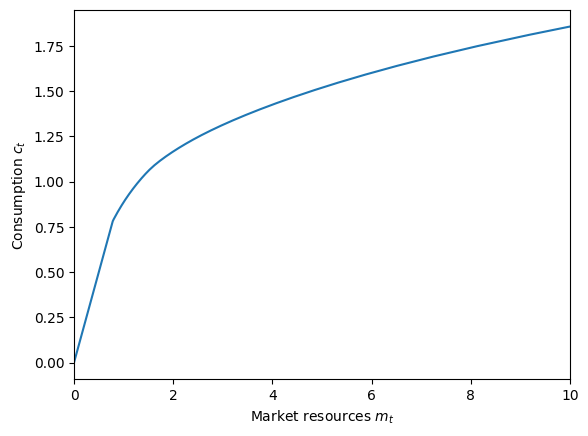

In [6]:
# Plot the consumption function in the first period of the model for the baseline consumer
BaseType.unpack("cFunc")
plot_funcs(
    BaseType.cFunc[0],
    0.0,
    10.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Consumption $c_t$",
)

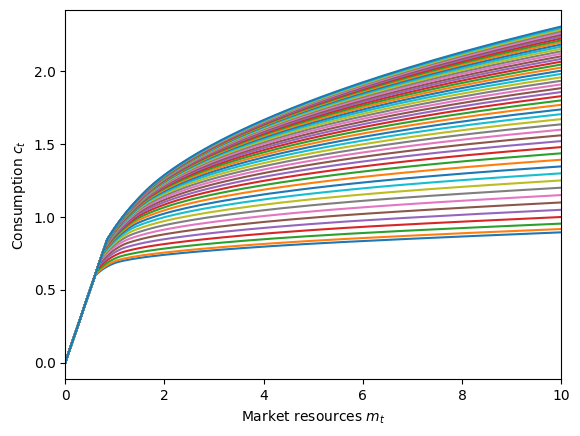

In [7]:
# Plot the consumption function in the first period of the model for consumers with habits
HabitType.unpack("cFunc")
plot_func_slices(
    HabitType.cFunc[0],
    0.0,
    10.0,
    Z=HabitType.HabitGrid,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Consumption $c_t$",
)

The consumption function for the baseline type is a 1D function that maps the market resources to permanent income ratio $m_t$ to the consumption to permanent income ratio $c_t$. For the habit-formation consumers, however, the consumption function depends on both $m_t$ and $h_t$, so we plot it at a variety of $h_t$ "slices". The lower curves represent the consumption function when the habit stock is low (compared to permanent income), so the consumer doesn't want to raise their consumption too quickly. The upper curves represent the consumption function when the habit stock is high (compared to permanent income), so the agent feels compelled to consume more due to their prior habits.

Let's see how the two models play out over the life-cycle in terms of saving behavior. We'll simulate each model from age 22 to age 95 and plot mean wealth holdings.

In [8]:
# Set up and simulate the baseline agents
t0 = time()
BaseType.initialize_sym(stop_dead=False)
BaseType.symulate()
t1 = time()
print("Simulating the baseline consumers took " + mystr(t1 - t0) + " seconds.")

Simulating the baseline consumers took 0.5871 seconds.


In [9]:
# Set up and simulate the habit-formation agents
t0 = time()
HabitType.initialize_sym(stop_dead=False)
HabitType.symulate()
t1 = time()
print("Simulating the habit-formation consumers took " + mystr(t1 - t0) + " seconds.")

Simulating the habit-formation consumers took 1.3023 seconds.


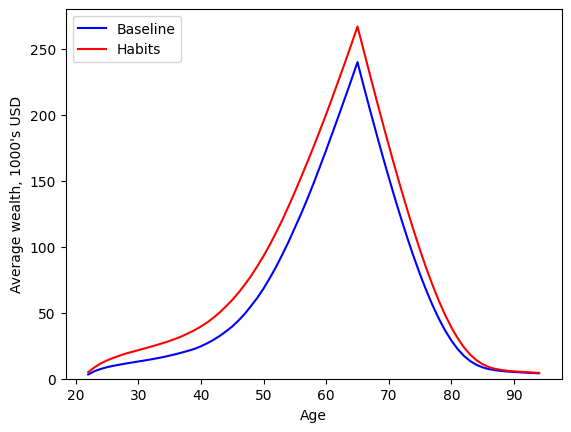

In [10]:
# Extract the history of assets from both consumer types, rescale by permanent income, and average across agents
aLvl_base = BaseType.hystory["aNrm"] * BaseType.hystory["pLvl"]
aLvl_habit = HabitType.hystory["aNrm"] * HabitType.hystory["pLvl"]
A_base = np.mean(aLvl_base, axis=1)
A_habit = np.mean(aLvl_habit, axis=1)

# Plot the two types' average wealth profile
age_vec = np.arange(22, 95)
plt.plot(age_vec, A_base, "-b")
plt.plot(age_vec, A_habit, "-r")
plt.legend(["Baseline", "Habits"], loc=2)
plt.xlabel("Age")
plt.ylabel("Average wealth, 1000's USD")
plt.ylim(0.0, None)
plt.show()

Hey, those are pretty similar wealth profiles! Yes, the *overall* life-cycle profile of wealth is very similar between the two models. The habit-formation consumer accumulates a bit more wealth than the baseline consumer for two reasons:

1) Consumers with habits anticipate that in old age, they will be unhappy if they have to decrease their consumption too quickly as they run out of assets. To plan ahead for this, they accumulate a bit more wealth throughout their working life in order to finance a slower decline in consumption later in life.

2) Very early in life, consumers *enter* the model with a consumption habit less than their permanent income. With the default parameters, initial $h_t$ averages about $0.6$-- maybe the agents were used to being poor college students before the model began. Thus their initial consumption levels will be *lower* than the baseline model, and consequently they accumulate more wealth early in their lifecycle.

We can see those effects more clearly if we plot life-cycle *consumption* profiles.

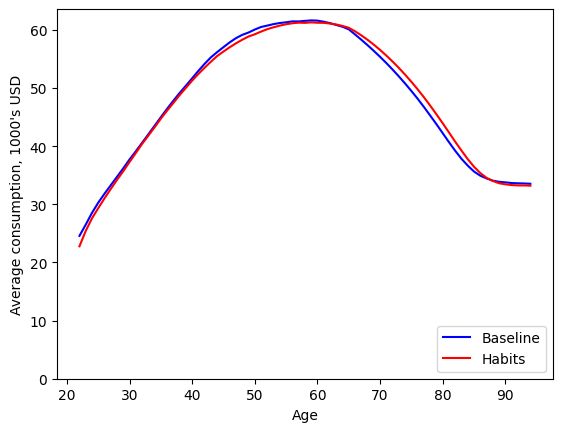

In [11]:
# Extract the history of consumption from both consumer types, rescale by permanent income, and average across agents
cLvl_base = BaseType.hystory["cNrm"] * BaseType.hystory["pLvl"]
cLvl_habit = HabitType.hystory["cNrm"] * HabitType.hystory["pLvl"]
C_base = np.mean(cLvl_base, axis=1)
C_habit = np.mean(cLvl_habit, axis=1)

# Plot the two types' average consumption profile
age_vec = np.arange(22, 95)
plt.plot(age_vec, C_base, "-b")
plt.plot(age_vec, C_habit, "-r")
plt.legend(["Baseline", "Habits"], loc=4)
plt.xlabel("Age")
plt.ylabel("Average consumption, 1000's USD")
plt.ylim(0.0, None)
plt.show()

The two models' predictions of behavior more starkly diverge when something *unexpected* happens. Let's run the same exercise again, but this time with a tragic event at age 67: shortly after retirement, everyone's savings are suddenly and unexpectedly *halved*.

The baseline consumers will immediately adjust to this turn of events by sharply decreasing their consumption. Consumers with strong habits, however, do not want to adjust so quickly; the sudden drop will be smaller, and then they will *gradually* reduce their consumption toward the lower sustainable level. This will cause their wealth to be drawn down faster than the baseline types, and eventually result in *lower* consumption in old age.

In [12]:
# Set up and simulate the baseline agents with a tragic loss of wealth
t0 = time()
BaseType.initialize_sym(stop_dead=False)
BaseType.symulate(45)  # simulate up to age 67
BaseType._simulator.data["aNrm"] *= 0.5  # the horror, the horror!
BaseType.symulate()  # simulate remaining periods
t1 = time()
print("Simulating the tragic baseline consumers took " + mystr(t1 - t0) + " seconds.")

Simulating the tragic baseline consumers took 0.5781 seconds.


In [13]:
# Set up and simulate the habit-formation agents with a tragic loss of wealth
t0 = time()
HabitType.initialize_sym(stop_dead=False)
HabitType.symulate(45)  # simulate up to age 67
HabitType._simulator.data["aNrm"] *= 0.5  # the horror, the horror!
HabitType.symulate()  # simulate remaining periods
t1 = time()
print(
    "Simulating the tragic habit-formation consumers took "
    + mystr(t1 - t0)
    + " seconds."
)

Simulating the tragic habit-formation consumers took 1.2823 seconds.


In [14]:
# Extract the history of assets from both consumer types, rescale by permanent income, and average across agents
aLvl_base_alt = BaseType.hystory["aNrm"] * BaseType.hystory["pLvl"]
aLvl_habit_alt = HabitType.hystory["aNrm"] * HabitType.hystory["pLvl"]
A_base_alt = np.mean(aLvl_base_alt, axis=1)
A_habit_alt = np.mean(aLvl_habit_alt, axis=1)

# Extract the history of consumption from both consumer types, rescale by permanent income, and average across agents
cLvl_base_alt = BaseType.hystory["cNrm"] * BaseType.hystory["pLvl"]
cLvl_habit_alt = HabitType.hystory["cNrm"] * HabitType.hystory["pLvl"]
C_base_alt = np.mean(cLvl_base_alt, axis=1)
C_habit_alt = np.mean(cLvl_habit_alt, axis=1)

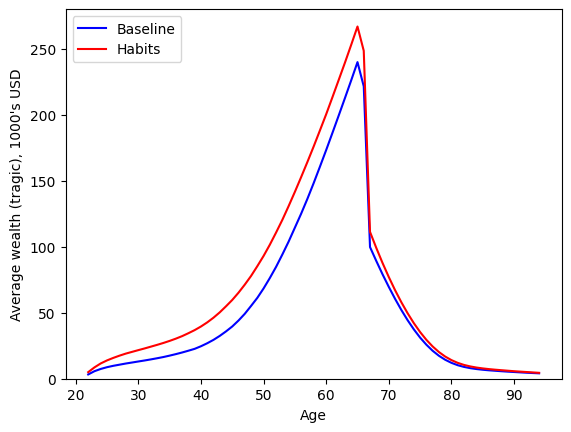

In [15]:
# Plot the two types' average wealth profile under the tragic scenario
age_vec = np.arange(22, 95)
plt.plot(age_vec, A_base_alt, "-b")
plt.plot(age_vec, A_habit_alt, "-r")
plt.legend(["Baseline", "Habits"], loc=2)
plt.xlabel("Age")
plt.ylabel("Average wealth (tragic), 1000's USD")
plt.ylim(0.0, None)
plt.show()

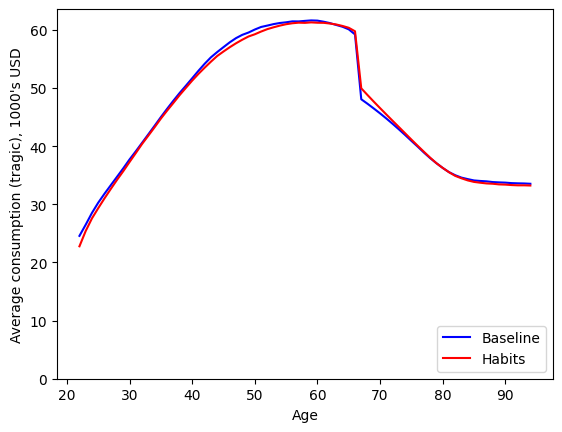

In [16]:
# Plot the two types' average consumption profile under the tragic scenario
age_vec = np.arange(22, 95)
plt.plot(age_vec, C_base_alt, "-b")
plt.plot(age_vec, C_habit_alt, "-r")
plt.legend(["Baseline", "Habits"], loc=4)
plt.xlabel("Age")
plt.ylabel("Average consumption (tragic), 1000's USD")
plt.ylim(0.0, None)
plt.show()